# 1. Persiapan Data

In [ ]:
import pandas as pd


df = pd.read_csv('INTC_stock_history.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11667 entries, 0 to 11666
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          11667 non-null  object 
 1   Open          11667 non-null  float64
 2   High          11667 non-null  float64
 3   Low           11667 non-null  float64
 4   Close         11667 non-null  float64
 5   Adj Close     11667 non-null  float64
 6   Volume        11667 non-null  int64  
 7   Dividends     11667 non-null  float64
 8   Stock Splits  11667 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 820.5+ KB


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11667 entries, 0 to 11666
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          11667 non-null  datetime64[ns]
 1   Open          11667 non-null  float64       
 2   High          11667 non-null  float64       
 3   Low           11667 non-null  float64       
 4   Close         11667 non-null  float64       
 5   Adj Close     11667 non-null  float64       
 6   Volume        11667 non-null  int64         
 7   Dividends     11667 non-null  float64       
 8   Stock Splits  11667 non-null  float64       
dtypes: datetime64[ns](1), float64(7), int64(1)
memory usage: 820.5 KB


# 2. Analisis Data

In [ ]:
# Cari baris data saat harga 'High' mencapai nilai maksimum (ATH)
df_modern = df[df['Date'] >= '2011-01-01'].copy()
baris_ath = df_modern.loc[df_modern['High'].idxmax()]

# Cari baris data saat harga 'Low' mencapai nilai minimum (ATL)
baris_atl = df_modern.loc[df_modern['Low'].idxmin()]

# 4. Tampilkan Hasilnya dengan f-string yang rapi
print("==================================================")
print(f"🚀 ALL-TIME HIGH (ATH) INTEL:")
print(f"📅 Tanggal : {baris_ath['Date'].strftime('%Y-%m-%d')}")
print(f"💰 Harga   : ${baris_ath['High']:.2f}")
print("==================================================")
print(f"📉 ALL-TIME LOW (ATL) INTEL:")
print(f"📅 Tanggal : {baris_atl['Date'].strftime('%Y-%m-%d')}")
print(f"💰 Harga   : ${baris_atl['Low']:.2f}")
print("==================================================")

🚀 ALL-TIME HIGH (ATH) INTEL:
📅 Tanggal : 2026-06-30
💰 Harga   : $142.35
📉 ALL-TIME LOW (ATL) INTEL:
📅 Tanggal : 2025-04-08
💰 Harga   : $17.67


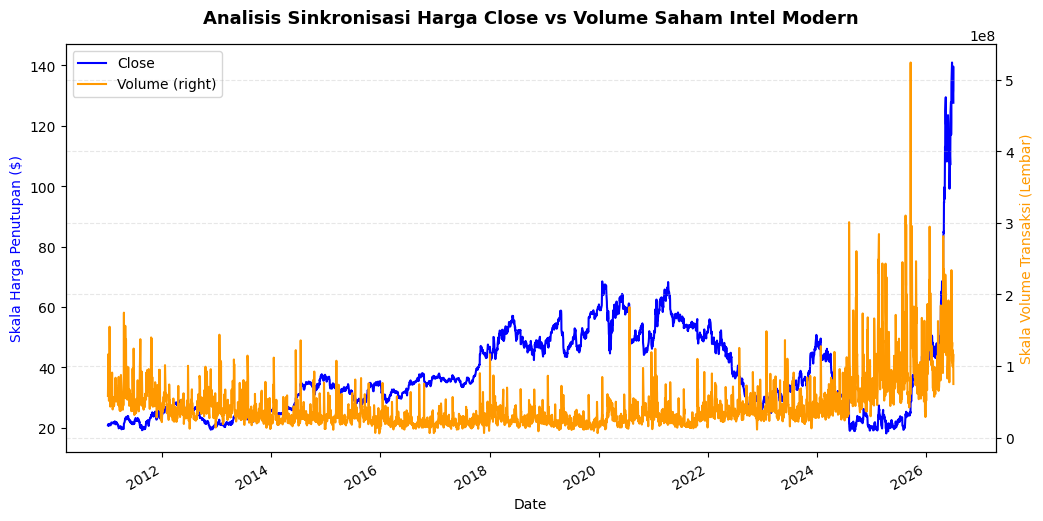

In [28]:
import matplotlib.pyplot as plt

# 1. Tangkap hasil plot ke dalam variabel 'ax'
ax = (
    df_modern.plot(
        kind='line',
        x='Date',
        y=['Close', 'Volume'],
        secondary_y=['Volume'],
        color=['blue', '#ff9900'],
        linewidth=1.5,
        figsize=(12, 6)
    )
)

# 2. Kustomisasi judul dan grid menggunakan plt seperti biasa
plt.title('Analisis Sinkronisasi Harga Close vs Volume Saham Intel Modern', fontsize=13, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.3)

# 3. Beri label sumbu Y kiri dan kanan melalui objek 'ax' yang tepat
ax.set_ylabel('Skala Harga Penutupan ($)', color='blue')
ax.right_ax.set_ylabel('Skala Volume Transaksi (Lembar)', color='#ff9900')

plt.show()

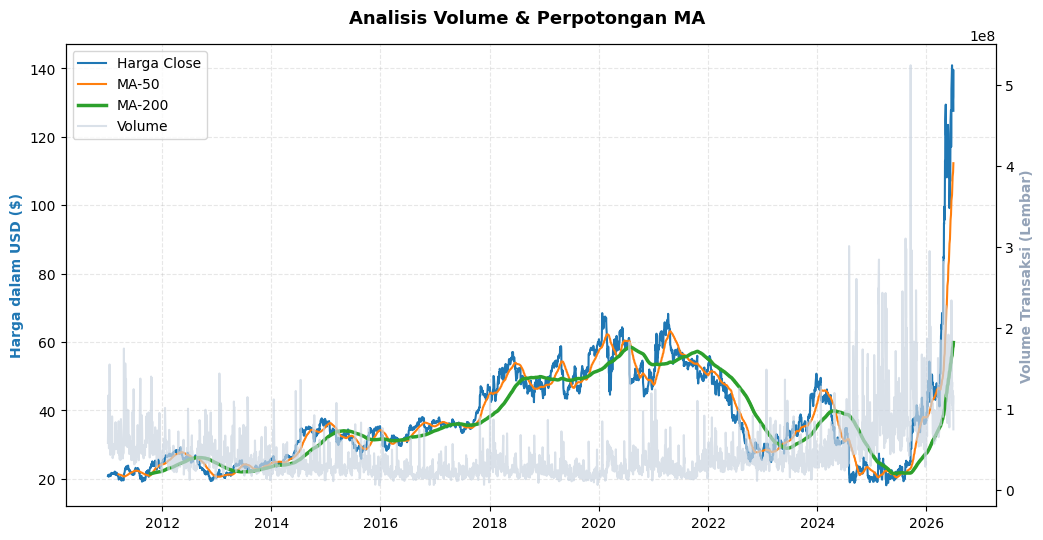

In [41]:
import matplotlib.pyplot as plt

# 1. Bikin kanvas dan tangkap sumbu pertamanya (ax1 = Sumbu Kiri)
fig, ax1 = plt.subplots(figsize=(12, 6))

# 2. Gambar semua yang berhubungan dengan HARGA di sumbu kiri (ax1)
ax1.plot(df_modern['Date'], df_modern['Close'], color='#1f77b4', linewidth=1.5, label='Harga Close')
ax1.plot(df_modern['Date'], df_modern['MA_50'], color='#ff7f0e', linewidth=1.5, label='MA-50')
ax1.plot(df_modern['Date'], df_modern['MA_200'], color='#2ca02c', linewidth=2.5, label='MA-200') # Langsung tebal di sini

# Kustomisasi Sumbu Kiri
ax1.set_ylabel('Harga dalam USD ($)', color='#1f77b4', fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.3)

# =========================================================================

# 3. MANTRA UTAMA: Kloning sumbu X untuk membuat sumbu kanan (ax2 = Sumbu Kanan)
ax2 = ax1.twinx()

# 4. Gambar VOLUME di sumbu kanan (ax2) + langsung set opacity (alpha) di sini
ax2.plot(df_modern['Date'], df_modern['Volume'], color='#cbd5e1', linewidth=1.5, alpha=0.7, label='Volume')

# Kustomisasi Sumbu Kanan
ax2.set_ylabel('Volume Transaksi (Lembar)', color='#94a3b8', fontweight='bold')

# =========================================================================

# 5. Satukan Legenda dari Dua Sumbu Berbeda agar Rapi dalam Satu Kotak
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Analisis Volume & Perpotongan MA ', fontsize=13, fontweight='bold', pad=15)
plt.show()